# NOAA Buoy Wave Data Plotting

Plot significant wave height time series from NOAA buoys 41110 and 41159.
This notebook can run standalone from command line or interactively in Jupyter.

In [5]:
from IPython.core.getipython import get_ipython

from wave_analysis_lib.core import setup_plot_style

# Detect runtime mode (Jupyter vs CLI)
try:
    if get_ipython() is not None:
        RUNNING_IN_JUPYTER = True
    else:
        RUNNING_IN_JUPYTER = False
except (ImportError, NameError):
    RUNNING_IN_JUPYTER = False

setup_plot_style()
print(f"Running in Jupyter: {RUNNING_IN_JUPYTER}")

Figure style set to: Arial, Bold, Italic
Running in Jupyter: True


In [6]:
# ===== NOTEBOOK PARAMETERS - EDIT THESE FOR YOUR USE CASE =====
# Paths are relative to scripts/python
# List of directories containing NOAA data files
data_dirs = [
    '../../data/meteo/NOAA_41159',
    '../../data/meteo/NOAA_41110'
]

# Output directory for plots
plot_dir = '../../plots'

# Optional: display plot interactively in notebook
show_plot = True
# ===== END PARAMETERS =====

In [7]:
from pathlib import Path

from wave_analysis_lib.core import validate_directories, load_and_plot_wave_data
from wave_analysis_lib.buoy_statistics import (
    compare_buoys_overlapping,
    calculate_buoy_statistics,
    print_comparison_statistics,
)
from wave_analysis_lib.wave_power import (
    load_survey_dates,
    reconstruct_buoy_dataframe,
    calculate_wave_power_between_surveys,
    save_wave_power_results,
)
from wave_analysis_lib.plotting import (
    plot_buoy_comparison,
    plot_wave_power_by_survey,
)

print('Loaded reusable functions from wave_analysis_lib/')

Loaded reusable functions from wave_analysis_lib/


Processing NOAA_41159: Found 8 data files
  Loaded: 41159h2015.txt
  Loaded: 41159h2016.txt
  Loaded: 41159h2017.txt
  Loaded: 41159h2018.txt
  Loaded: 41159h2019.txt
  Loaded: 41159h2020.txt
  Loaded: 41159h2021.txt
  Loaded: 41159h2022.txt
Processing NOAA_41110: Found 18 data files
  Loaded: 41110h2008.txt
  Loaded: 41110h2009.txt
  Loaded: 41110h2010.txt
  Loaded: 41110h2011.txt
  Loaded: 41110h2012.txt
  Loaded: 41110h2013.txt
  Loaded: 41110h2014.txt
  Loaded: 41110h2015.txt
  Loaded: 41110h2016.txt
  Loaded: 41110h2017.txt
  Loaded: 41110h2018.txt
  Loaded: 41110h2019.txt
  Loaded: 41110h2020.txt
  Loaded: 41110h2021.txt
  Loaded: 41110h2022.txt
  Loaded: 41110h2023.txt
  Loaded: 41110h2024.txt
  Loaded: 41110h2025.txt

Figure saved to: C:\surf\500_Analysis\522_CarolinaInlets\plots\NOAA_Buoys_41110_41159_Wave_Height.png


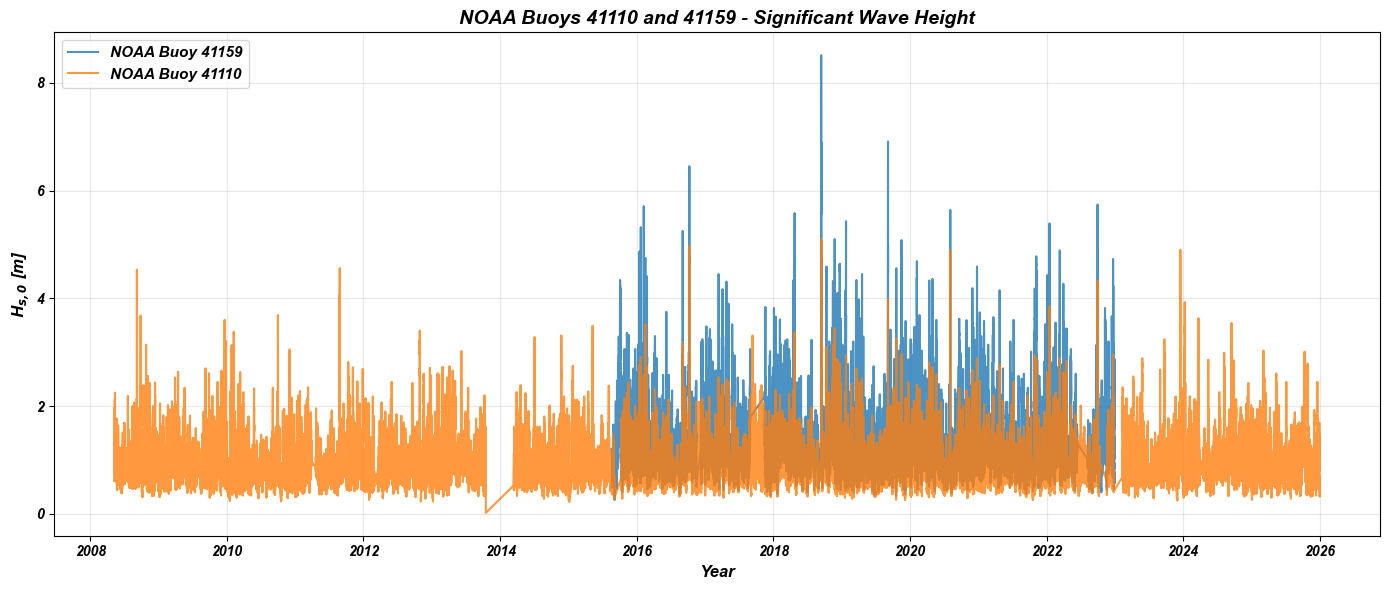


BUOY REPRESENTATIVENESS ANALYSIS
Overlapping period: 2015-08-21 to 2022-12-31
  NOAA_41159: 115660 records (before alignment)
  NOAA_41110: 121375 records (before alignment)
  Aligned data: 38538 common time points

BUOY COMPARISON STATISTICS: NOAA_41159 vs NOAA_41110

--- CORRELATION ---
Pearson r: 0.8734 (p-value: 0.00e+00)
Spearman rho: 0.8356 (p-value: 0.00e+00)

--- LINEAR REGRESSION: Hs(41159) = a*Hs(41110) + b ---
Slope (a): 0.5436
Intercept (b): 0.2026
R^2: 0.7628 (p-value: 0.00e+00)

--- BASIC STATISTICS ---
NOAA_41159           | NOAA_41110          
Mean Hs:   1.36 m    |   0.94 m
Std Dev:   0.69 m    |   0.43 m
Median:    1.19 m    |   0.84 m
Max:       8.51 m    |   5.10 m

--- DISTRIBUTION TEST (Kolmogorov-Smirnov) ---
KS statistic: 0.3414 (p-value: 0.00e+00)
  -> Distributions ARE significantly different (reject H0)

--- STORM EXCEEDANCE (Hs > 2m, per Splinter et al.) ---
NOAA_41159: 5204 events (13.5%)
NOAA_41110: 1100 events (2.9%)

Creating comparison plots...
Figure

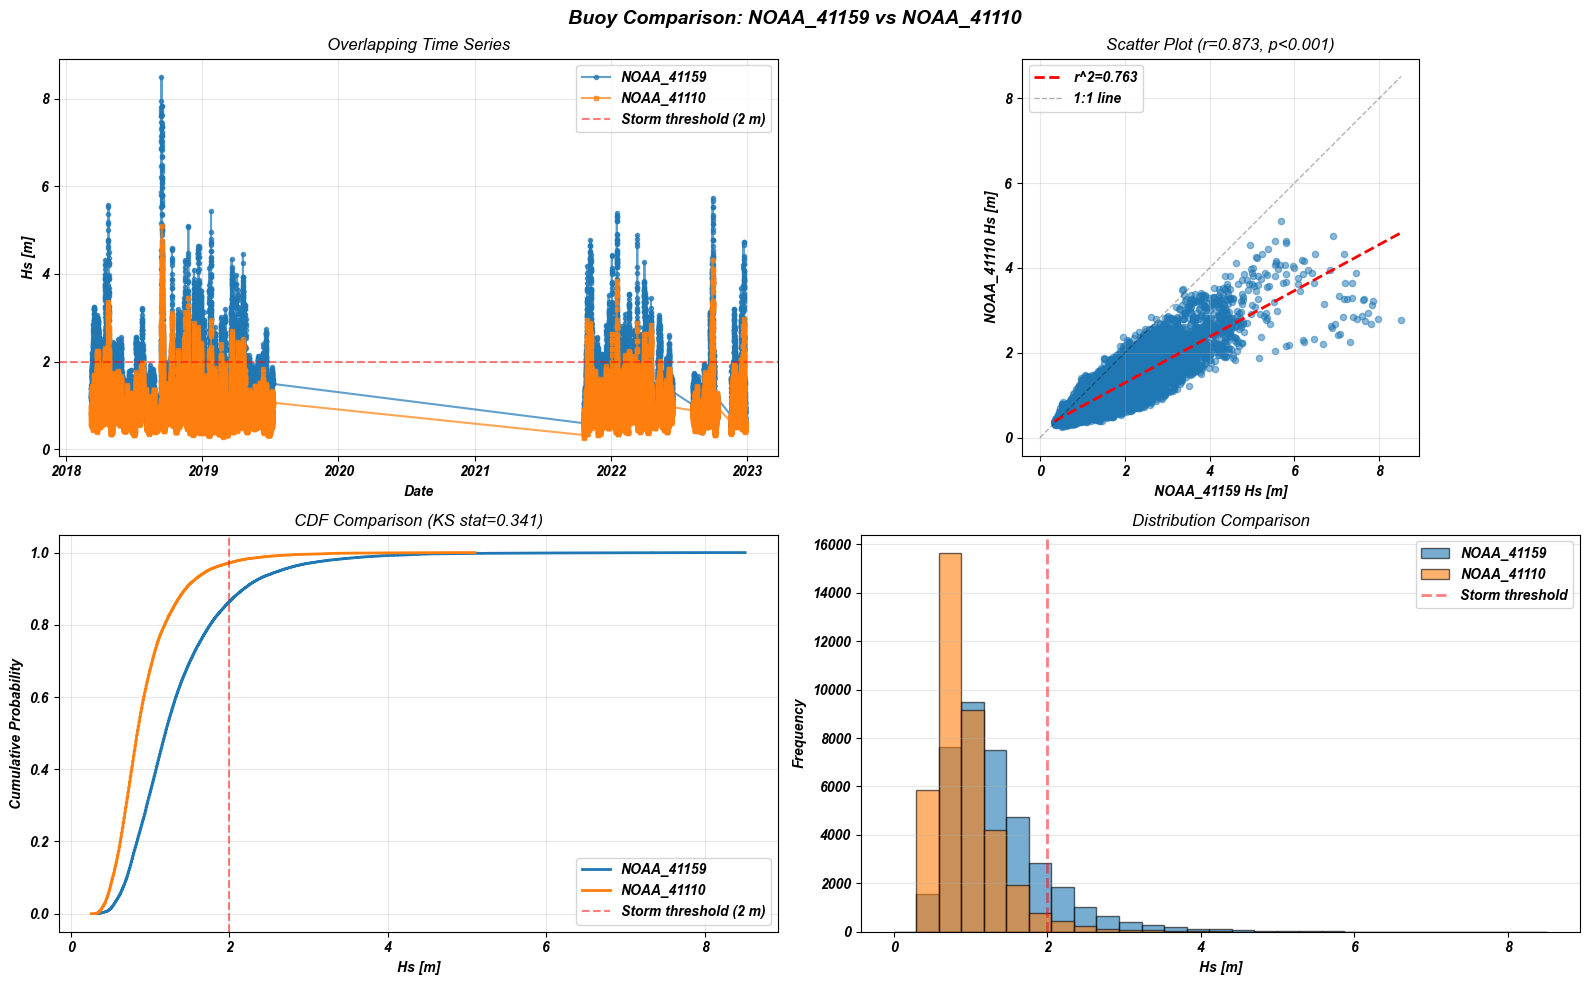


CUMULATIVE WAVE POWER ANALYSIS (Splinter et al. 2014)

Loaded 24 survey dates:
  From: 2005-01-01
  To:   2023-12-01

Reconstructing buoy data with wave period information...
Calculating cumulative wave power between survey dates...

Wave Power Summary:
      buoy  survey_idx start_date   end_date  period_days  cum_wave_power_MWh_m  mean_Hs  max_Hs  n_records
NOAA_41110           1 2007-06-01 2009-01-01          580             13.747280 0.959126    4.53      11038
NOAA_41110           2 2009-01-01 2012-03-01         1155             56.929359 0.915206    4.56      51961
NOAA_41110           3 2012-03-01 2013-08-01          518             26.277715 0.949263    3.40      22822
NOAA_41110           4 2013-08-01 2014-04-01          243              6.037052 0.884069    2.26       4382
NOAA_41110           5 2014-04-01 2015-06-01          426             21.471630 0.927940    3.49      19236
NOAA_41159           6 2015-06-01 2015-11-01          153             10.632110 1.442403    4.34 

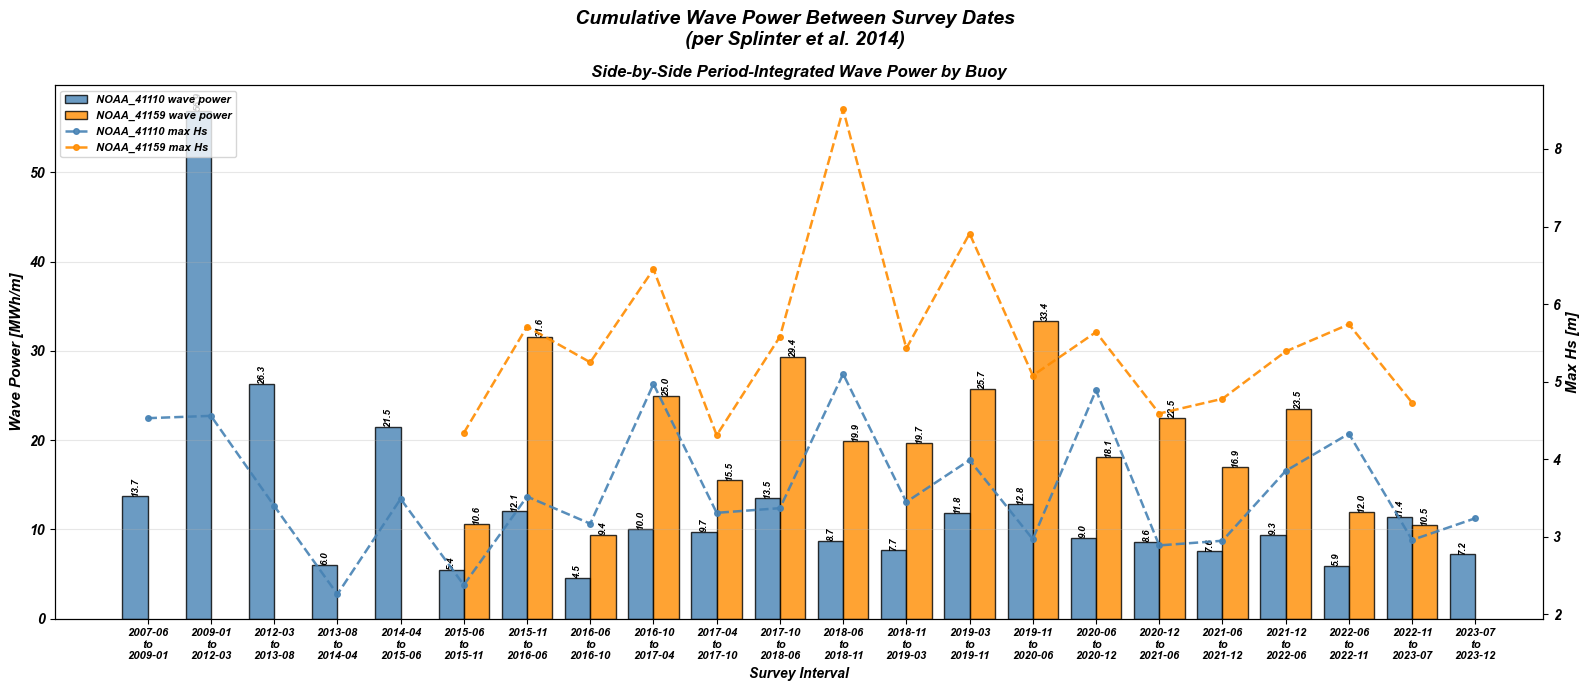


ANALYSIS COMPLETE


In [ ]:
if RUNNING_IN_JUPYTER:
    # Load and plot buoy wave data
    validated_data_dirs, validated_plot_dir = validate_directories(data_dirs, plot_dir)
    buoy_data, fig = load_and_plot_wave_data(
        validated_data_dirs,
        validated_plot_dir,
        show_plot=show_plot,
        running_in_jupyter=RUNNING_IN_JUPYTER,
    )

    # Buoy comparison analysis
    print("\n" + "="*70)
    print("BUOY REPRESENTATIVENESS ANALYSIS")
    print("="*70)

    df_buoy1, df_buoy2, buoy_names = compare_buoys_overlapping(buoy_data)

    if df_buoy1 is not None:
        comparison_stats = calculate_buoy_statistics(df_buoy1, df_buoy2, buoy_names)
        print_comparison_statistics(comparison_stats, buoy_names)
        print("Creating comparison plots...")
        plot_buoy_comparison(
            df_buoy1,
            df_buoy2,
            buoy_names,
            comparison_stats,
            validated_plot_dir,
            running_in_jupyter=RUNNING_IN_JUPYTER,
        )

    # Wave power analysis
    print("\n" + "="*70)
    print("CUMULATIVE WAVE POWER ANALYSIS (Splinter et al. 2014)")
    print("="*70)

    survey_dates_file = Path('../../data/surveyDates.txt').resolve()
    if survey_dates_file.exists():
        survey_dates = load_survey_dates(survey_dates_file)
        print(f"\nLoaded {len(survey_dates)} survey dates:")
        print(f"  From: {survey_dates[0].date()}")
        print(f"  To:   {survey_dates[-1].date()}")

        print("\nReconstructing buoy data with wave period information...")
        buoy_dfs = reconstruct_buoy_dataframe(buoy_data)

        print("Calculating cumulative wave power between survey dates...")
        wave_power_results = calculate_wave_power_between_surveys(buoy_dfs, survey_dates)

        if not wave_power_results.empty:
            print("\nWave Power Summary:")
            print(wave_power_results.to_string(index=False))

            wave_power_stats_file = validated_plot_dir / 'Cumulative_Wave_Power_Stats.txt'
            save_wave_power_results(wave_power_results, wave_power_stats_file)

            print("\nCreating wave power plots...")
            plot_wave_power_by_survey(
                wave_power_results,
                validated_plot_dir,
                running_in_jupyter=RUNNING_IN_JUPYTER,
            )
        else:
            print("No wave power data calculated.")
    else:
        print(f"Warning: Survey dates file not found: {survey_dates_file}")

    print("\n" + "="*70)
    print("ANALYSIS COMPLETE")
    print("="*70)
else:
    print("Non-Jupyter mode - use command line execution")